
## Chapter 9: Decision Trees - Regression Decision Tree

### Importing the necessary packages

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

### Plotting functions

In [2]:
# Some functions to plot our points and draw the models

def display_tree(dt):
    import six
    import sys
    sys.modules['sklearn.externals.six'] = six
    from IPython.display import Image
    from sklearn.tree import export_graphviz
    import pydotplus
    dot_data = six.StringIO()
    export_graphviz(dt, out_file=dot_data,
                    filled=True, rounded=True,
                    special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return Image(graph.create_png())

def plot_regressor(model, features, labels):
    x = np.linspace(0,85,1000)
    plt.scatter(features, labels)
    plt.plot(x, model.predict(x.reshape([-1,1])))
    plt.xlabel("Age")
    plt.ylabel("Days per week")
    plt.show()

### Defining and plotting our dataset

In [3]:
features = [[10],[20],[30],[40],[50],[60],[70],[80]]
labels = [7,5,7,1,2,1,5,4]

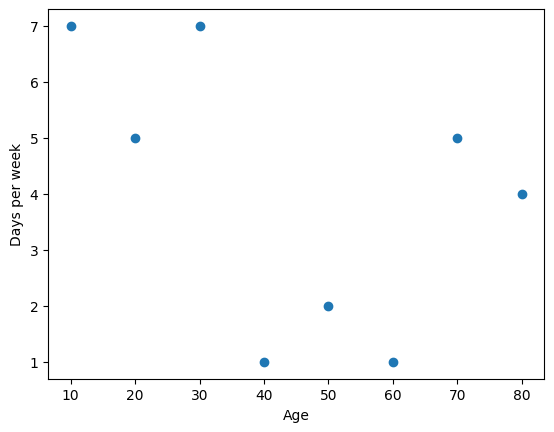

In [4]:
plt.scatter(features, labels)
plt.xlabel("Age")
plt.ylabel("Days per week")
plt.show()



### Building a decision tree (Regression) using Gini index



In [5]:
dt_regressor = DecisionTreeRegressor(max_depth=2)
dt_regressor.fit(features, labels)

DecisionTreeRegressor(max_depth=2)

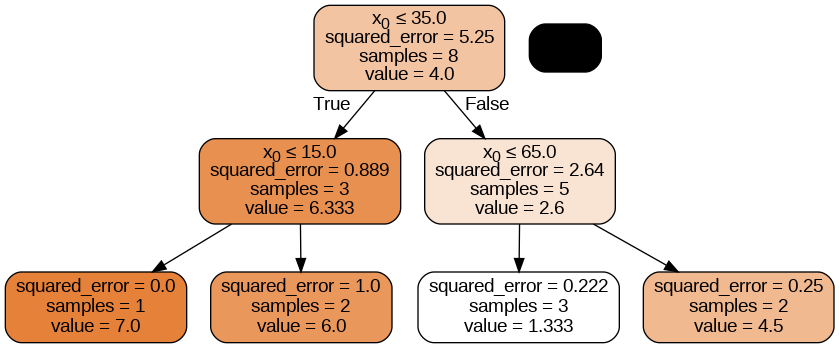

In [6]:
display_tree(dt_regressor)

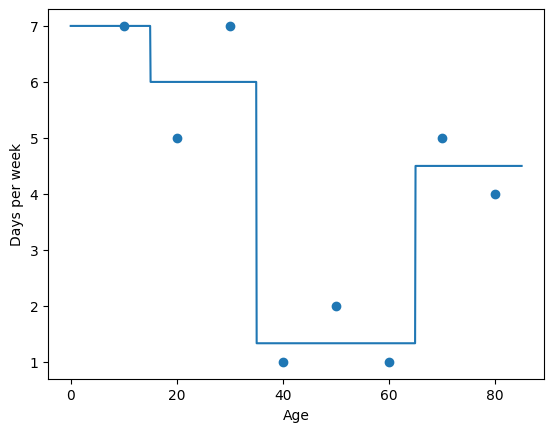

In [9]:
plot_regressor(dt_regressor, features, labels)

### Finding the first split by mimizing the MSE


In [10]:
for i in range(0,9):
    left = np.array(labels[:i])
    right = np.array(labels[i:])
    print("*****")
    print(left, right)
    print(np.mean(left), np.mean(right))
    left_tse = left-np.mean(left)
    right_tse = right-np.mean(right)
    print(1/8*(np.dot(left_tse, left_tse) + np.dot(right_tse, right_tse)))

*****
[] [7 5 7 1 2 1 5 4]
nan 4.0
5.25
*****
[7] [5 7 1 2 1 5 4]
7.0 3.5714285714285716
3.9642857142857144
*****
[7 5] [7 1 2 1 5 4]
6.0 3.3333333333333335
3.916666666666667
*****
[7 5 7] [1 2 1 5 4]
6.333333333333333 2.6
1.9833333333333334
*****
[7 5 7 1] [2 1 5 4]
5.0 3.0
4.25
*****
[7 5 7 1 2] [1 5 4]
4.4 3.3333333333333335
4.983333333333333
*****
[7 5 7 1 2 1] [5 4]
3.8333333333333335 4.5
5.166666666666667
*****
[7 5 7 1 2 1 5] [4]
4.0 4.0
5.25
*****
[7 5 7 1 2 1 5 4] []
4.0 nan
5.25


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [11]:
1/8*(
    (7-3.833)**2 +
    (5-3.833)**2 +
    (7-3.833)**2 +
    (1-3.833)**2 +
    (2-3.833)**2 +
    (1-3.833)**2 +
    (5-4.5)**2 +
    (4-4.5)**2)

5.16666675

In [12]:
np.array([7,5,7,1,2,1,5,4]).mean()

np.float64(4.0)